# 01 Explore: load, verify, label, split

Goal of this notebook: check the raw data is what we think it is, then compute the numbers needed for two decisions:
1. **Label**: A "involved" vs B "pass-through mule"
2. **Cut date** for the time-based train/test split

`Is Laundering` is used here only to count positives. Patterns.txt is only parsed to count typologies; it never becomes a feature.

In [1]:
import os, sys
from pathlib import Path
# Run from the repo root so relative paths in config.yaml work
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from src.load import load_config, check_header, build_parquet, parse_patterns

pd.set_option("display.width", 200)
cfg = load_config()
PARQUET = cfg["data"]["transactions_parquet"]
if not Path(PARQUET).exists():
    build_parquet(cfg["data"]["raw_csv"], PARQUET)

con = duckdb.connect()
con.sql("SET enable_progress_bar = false")  # keeps notebook output clean
con.sql(f"CREATE OR REPLACE VIEW t AS SELECT * FROM '{PARQUET}'")
q = lambda sql: con.sql(sql).df()

## 1. Verify the raw file
The header has two columns both named `Account`: sender first, receiver second. `check_header` fails loudly if that ever changes.

In [2]:
print(check_header(cfg["data"]["raw_csv"]))
q("DESCRIBE t")

['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


,column_name,column_type,null,key,default,extra
0,txn_id,BIGINT,YES,None,None,None
1,ts,TIMESTAMP,YES,None,None,None
2,src,VARCHAR,YES,None,None,None
3,dst,VARCHAR,YES,None,None,None
4,from_bank,VARCHAR,YES,None,None,None
5,to_bank,VARCHAR,YES,None,None,None
6,amount_received,DOUBLE,YES,None,None,None
7,receiving_currency,VARCHAR,YES,None,None,None
8,amount_paid,DOUBLE,YES,None,None,None
9,payment_currency,VARCHAR,YES,None,None,None


In [3]:
q("""
SELECT count(*)                           AS n_txn,
       min(ts)                            AS first_ts,
       max(ts)                            AS last_ts,
       sum(is_laundering)::INT            AS n_laundering,
       round(100 * avg(is_laundering), 4) AS laundering_pct,
       sum((ts IS NULL OR src IS NULL OR dst IS NULL OR amount_paid IS NULL)::INT) AS rows_with_nulls
FROM t
""")

,n_txn,first_ts,last_ts,n_laundering,laundering_pct,rows_with_nulls
0,5078345,2022-09-01,2022-09-18 16:18:00,5177,0.1019,0.0


### Why account ID = bank + account number
If account numbers were unique on their own, the two counts below would be equal. Any gap means the same account number exists at more than one bank, and using the number alone would merge two different customers.

In [4]:
q("""
WITH ids AS (
    SELECT src AS account_id, split_part(src, '_', 2) AS acct_number FROM t
    UNION
    SELECT dst, split_part(dst, '_', 2) FROM t
)
SELECT count(*) AS n_account_ids, count(DISTINCT acct_number) AS n_distinct_account_numbers
FROM ids
""")

,n_account_ids,n_distinct_account_numbers
0,515088,515080


## 2. Transactions per day

In [5]:
daily = q("""
SELECT ts::DATE AS day,
       count(*)                           AS n_txn,
       sum(is_laundering)::INT            AS n_laundering,
       round(100 * avg(is_laundering), 3) AS laundering_pct
FROM t GROUP BY 1 ORDER BY 1
""")
daily["weekday"] = pd.to_datetime(daily["day"]).dt.day_name().str[:3]
daily

,day,n_txn,n_laundering,laundering_pct,weekday
0,2022-09-01,1114921,322,0.029,Thu
1,2022-09-02,754449,408,0.054,Fri
2,2022-09-03,207382,391,0.189,Sat
3,2022-09-04,207430,407,0.196,Sun
4,2022-09-05,482650,471,0.098,Mon
5,2022-09-06,482089,531,0.110,Tue
6,2022-09-07,482751,497,0.103,Wed
7,2022-09-08,482773,539,0.112,Thu
8,2022-09-09,654467,514,0.079,Fri
9,2022-09-10,208325,442,0.212,Sat


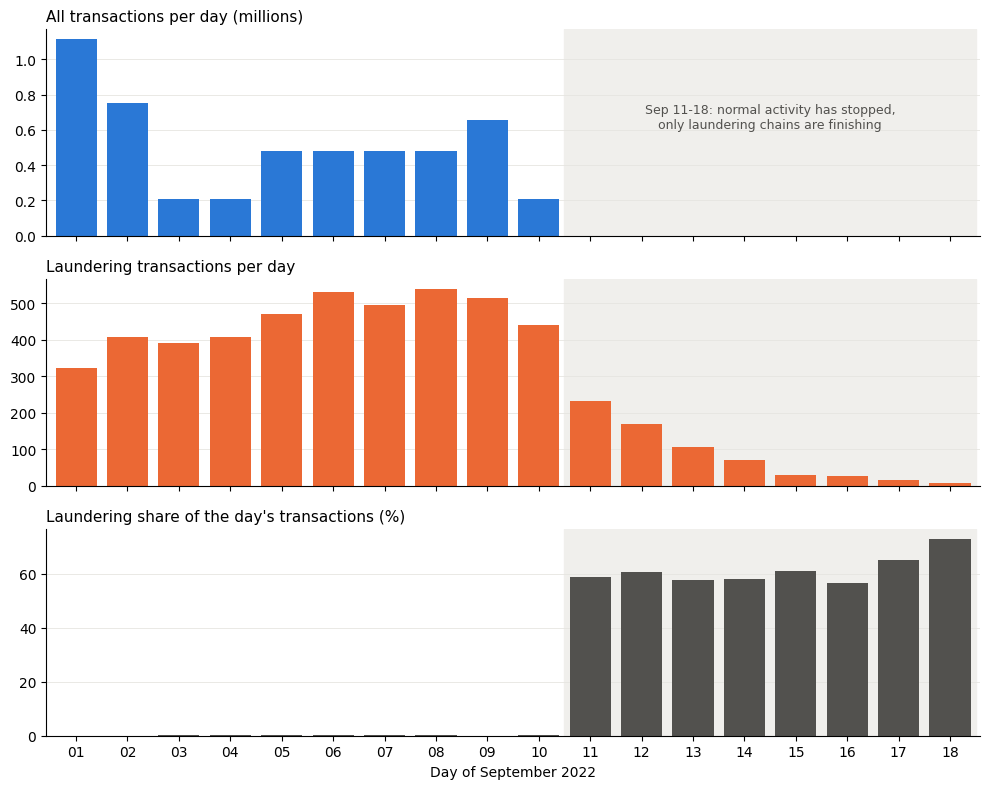

In [6]:
# Separate panels, not a dual axis: the two counts differ by ~1000x in scale
days = pd.to_datetime(daily["day"])
daily["n_txn_m"] = daily["n_txn"] / 1e6
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
panels = [("n_txn_m", "All transactions per day (millions)", "#2a78d6"),
          ("n_laundering", "Laundering transactions per day", "#eb6834"),
          ("laundering_pct", "Laundering share of the day's transactions (%)", "#52514e")]
for ax, (col, title, colour) in zip(axes, panels):
    ax.bar(days, daily[col], color=colour, width=0.8)
    ax.axvspan(pd.Timestamp("2022-09-10 12:00"), days.max() + pd.Timedelta("12h"), color="#f0efec", zorder=0)
    ax.set_title(title, loc="left", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e6e5e1", linewidth=0.6)
    ax.set_axisbelow(True)
axes[0].text(pd.Timestamp("2022-09-14 12:00"), daily["n_txn_m"].max() * 0.55,
             "Sep 11-18: normal activity has stopped,\nonly laundering chains are finishing",
             ha="center", fontsize=9, color="#52514e")
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d"))
axes[-1].set_xlim(days.min() - pd.Timedelta("14h"), days.max() + pd.Timedelta("14h"))
axes[-1].set_xlabel("Day of September 2022")
fig.tight_layout()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("reports/figures/01_daily_counts.png", dpi=150)
plt.show()

**What this shows**
- Normal activity runs **Sep 1 to Sep 10**. From Sep 11 almost nothing happens except laundering: the simulator stopped generating normal customers but let started laundering chains finish.
- Weekends (Sep 3-4, Sep 10) are quieter. Sep 1 is unusually large, which looks like the simulator warming up.
- The tail matters for the split: any account active after Sep 10 is almost certainly involved in laundering. If the tail ends up in the test set, the model gets an easy giveaway that would never happen at a real bank.

In [7]:
q("""
WITH tail AS (SELECT * FROM t WHERE ts >= '2022-09-11'),
     tail_accounts AS (SELECT src AS id FROM tail UNION SELECT dst FROM tail),
     involved AS (SELECT src AS id FROM t WHERE is_laundering = 1 UNION SELECT dst FROM t WHERE is_laundering = 1)
SELECT (SELECT count(*) FROM tail)                    AS tail_txn,
       (SELECT sum(is_laundering)::INT FROM tail)     AS tail_laundering_txn,
       count(*)                                       AS tail_accounts,
       sum((id IN (SELECT id FROM involved))::INT)    AS tail_accounts_ever_in_laundering
FROM tail_accounts
""")

,tail_txn,tail_laundering_txn,tail_accounts,tail_accounts_ever_in_laundering
0,1108,655,716,716.0


## 3. Payment formats, currencies, cross-bank, self-transfers

In [8]:
q("""
SELECT payment_format,
       count(*)                           AS n_txn,
       sum(is_laundering)::INT            AS n_laundering,
       round(100 * avg(is_laundering), 3) AS laundering_pct,
       round(100 * sum(is_laundering) / (SELECT sum(is_laundering) FROM t), 1) AS share_of_all_laundering_pct
FROM t GROUP BY 1 ORDER BY n_txn DESC
""")

,payment_format,n_txn,n_laundering,laundering_pct,share_of_all_laundering_pct
0,Cheque,1864331,324,0.017,6.3
1,Credit Card,1323324,206,0.016,4.0
2,ACH,600797,4483,0.746,86.6
3,Cash,490891,108,0.022,2.1
4,Reinvestment,481056,0,0.000,0.0
5,Wire,171855,0,0.000,0.0
6,Bitcoin,146091,56,0.038,1.1


In [9]:
q("""
SELECT payment_currency, count(*) AS n_txn, sum(is_laundering)::INT AS n_laundering
FROM t GROUP BY 1 ORDER BY n_txn DESC
""")

,payment_currency,n_txn,n_laundering
0,US Dollar,1895172,1912
1,Euro,1168297,1372
2,Swiss Franc,234860,193
3,Yuan,213752,184
4,Shekel,192184,95
5,Rupee,190202,167
6,UK Pound,180738,132
7,Yen,155209,155
8,Ruble,155178,133
9,Bitcoin,146066,56


In [10]:
q("""
SELECT 'currency mismatch (paid != received currency)' AS slice, count(*) AS n_txn,
       coalesce(sum(is_laundering), 0)::INT AS n_laundering
FROM t WHERE payment_currency <> receiving_currency
UNION ALL
SELECT 'cross-bank (from_bank != to_bank)', count(*), sum(is_laundering)::INT
FROM t WHERE from_bank <> to_bank
UNION ALL
SELECT 'self-transfer (src = dst)', count(*), sum(is_laundering)::INT
FROM t WHERE src = dst
""")

,slice,n_txn,n_laundering
0,currency mismatch (paid != received currency),72170,0
1,cross-bank (from_bank != to_bank),4387090,5074
2,self-transfer (src = dst),591212,11


**Notes for the feature and rule phases**
- Laundering is concentrated in **ACH**. Cash and Bitcoin carry little of it, and Wire and Reinvestment carry none. So R5 HIGH_RISK_CHANNEL (cash/bitcoin) will probably be weak on this data. That is a property of the simulator, not of real Indian mule chains, where cash-out is the last step.
- Currency mismatch has **zero** laundering transactions, so the currency-mismatch feature cannot help here.
- Most transactions are cross-bank, laundering or not, so cross-bank share alone will not separate much.
- Self-transfers (Reinvestment) are mostly normal. A self-transfer is not money moving onward, so we exclude it when defining "pass-through".

## 4. Patterns file (evaluation only)
Parsed once here just to see which typologies exist. It is not used again until Phase 5.

In [11]:
patterns = parse_patterns(cfg["data"]["patterns_txt"])
by_typology = (patterns.groupby("typology")
               .agg(attempts=("attempt_id", "nunique"), transactions=("attempt_id", "size"))
               .sort_values("transactions", ascending=False))
by_typology

,attempts,transactions
typology,,
GATHER-SCATTER,51,716
SCATTER-GATHER,44,626
STACK,43,466
FAN-OUT,48,342
FAN-IN,40,318
CYCLE,54,287
BIPARTITE,49,263
RANDOM,41,191


In [12]:
# Do the pattern transactions cover all laundering rows in the CSV?
con.register("patterns_df", patterns)
q("""
WITH laundering AS (SELECT DISTINCT ts, src, dst, amount_paid FROM t WHERE is_laundering = 1),
     pat AS (SELECT DISTINCT ts, src, dst, amount_paid FROM patterns_df)
SELECT (SELECT count(*) FROM laundering) AS laundering_rows_in_csv,
       (SELECT count(*) FROM pat)        AS rows_in_patterns,
       (SELECT count(*) FROM laundering l JOIN pat p USING (ts, src, dst, amount_paid)) AS matched
""")

,laundering_rows_in_csv,rows_in_patterns,matched
0,5177,3209,3209


Laundering rows that are not in Patterns.txt have no typology tag. In Phase 5, typology recall only covers accounts that can be linked to a pattern, and the README will say so.

## 5. Label options

For each account, inside a given window:
- **A "Involved"**: sent or received at least 1 laundering transaction.
- **B "Pass-through mule"**: received at least 1 AND sent at least 1 laundering transaction (self-transfers excluded).

The label depends on the window: an account can be B in a long window but only A in a short one, if the money comes in on one side of the cut and goes out on the other.

In [13]:
def label_counts(where, name):
    """Account counts under label A and B for transactions matching `where`."""
    return q(f"""
    WITH w AS (SELECT * FROM t WHERE {where}),
    flows AS (   -- one row per account per transaction side, counting only non-self laundering
        SELECT src AS id, is_laundering * (src <> dst)::INT AS laund_out, 0 AS laund_in FROM w
        UNION ALL
        SELECT dst, 0, is_laundering * (src <> dst)::INT FROM w
    ),
    acct AS (
        SELECT id, sum(laund_out) AS l_out, sum(laund_in) AS l_in FROM flows GROUP BY id
    )
    SELECT '{name}' AS window,
           (SELECT count(*) FROM w)                AS n_txn,
           (SELECT sum(is_laundering)::INT FROM w) AS n_laundering_txn,
           count(*)                                AS n_accounts,
           sum((l_in + l_out > 0)::INT)            AS label_A,
           sum((l_in > 0 AND l_out > 0)::INT)      AS label_B,
           round(100.0 * sum((l_in + l_out > 0)::INT) / count(*), 3)       AS A_pct,
           round(100.0 * sum((l_in > 0 AND l_out > 0)::INT) / count(*), 3) AS B_pct
    FROM acct""")

label_counts("ts < '2022-09-11'", "Sep 1-10 (no tail)")

,window,n_txn,n_laundering_txn,n_accounts,label_A,label_B,A_pct,B_pct
0,Sep 1-10 (no tail),5077237,4522,515078,5862.0,795.0,1.138,0.154


## 6. Candidate cut dates
Train = before the cut. Test = cut date to the end of Sep 10, shown both without and with the Sep 11-18 tail.

In [14]:
rows = []
for cut in ["2022-09-07", "2022-09-08", "2022-09-09"]:
    rows.append(label_counts(f"ts < '{cut}'", f"train  < {cut}"))
    rows.append(label_counts(f"ts >= '{cut}' AND ts < '2022-09-11'", f"test   {cut} .. Sep 10"))
    rows.append(label_counts(f"ts >= '{cut}'", f"test   {cut} .. Sep 18 (with tail)"))
split_table = pd.concat(rows, ignore_index=True)
split_table

,window,n_txn,n_laundering_txn,n_accounts,label_A,label_B,A_pct,B_pct
0,train < 2022-09-07,3248921,2530,512907,3471.0,340.0,0.677,0.066
1,test 2022-09-07 .. Sep 10,1828316,1992,367656,2693.0,322.0,0.732,0.088
2,test 2022-09-07 .. Sep 18 (with tail),1829424,2647,367781,3200.0,536.0,0.870,0.146
3,train < 2022-09-08,3731672,3027,513512,4064.0,460.0,0.791,0.090
4,test 2022-09-08 .. Sep 10,1345565,1495,361433,2134.0,182.0,0.590,0.050
5,test 2022-09-08 .. Sep 18 (with tail),1346673,2150,361568,2652.0,394.0,0.733,0.109
6,train < 2022-09-09,4214445,3566,514022,4714.0,593.0,0.917,0.115
7,test 2022-09-09 .. Sep 10,862792,956,354447,1397.0,97.0,0.394,0.027
8,test 2022-09-09 .. Sep 18 (with tail),863900,1611,354590,1940.0,294.0,0.547,0.083


### Why not a random split?
A random split puts transactions from the same account, and from its direct counterparties, into both train and test. Mule chains are linked: if account X's incoming laundering transfer is in train and its outgoing one is in test, the model has effectively seen part of the answer. A time split copies real deployment: train on the past, score the future.

Below: how many test positives were already positive in train, and how many were active in train at all. That is the realistic "known account" overlap a bank would also have.

In [15]:
def positives(where, label):
    cond = "l_in + l_out > 0" if label == "A" else "l_in > 0 AND l_out > 0"
    return f"""(SELECT id FROM (
        SELECT id, sum(lo) AS l_out, sum(li) AS l_in FROM (
            SELECT src AS id, is_laundering * (src <> dst)::INT AS lo, 0 AS li FROM t WHERE {where}
            UNION ALL
            SELECT dst, 0, is_laundering * (src <> dst)::INT FROM t WHERE {where}
        ) GROUP BY id) WHERE {cond})"""

rows = []
for cut in ["2022-09-07", "2022-09-08"]:
    test_where = f"ts >= '{cut}' AND ts < '2022-09-11'"
    for label in ["A", "B"]:
        rows.append(q(f"""
        SELECT '{cut}' AS cut, '{label}' AS label, count(*) AS test_positives,
               sum((id IN {positives(f"ts < '{cut}'", label)})::INT) AS also_positive_in_train,
               sum((id IN (SELECT src FROM t WHERE ts < '{cut}' UNION SELECT dst FROM t WHERE ts < '{cut}'))::INT) AS active_in_train
        FROM {positives(test_where, label)}"""))
pd.concat(rows, ignore_index=True)

,cut,label,test_positives,also_positive_in_train,active_in_train
0,2022-09-07,A,2693,302.0,2636.0
1,2022-09-07,B,322,17.0,318.0
2,2022-09-08,A,2134,336.0,2095.0
3,2022-09-08,B,182,21.0,180.0


## 7. Other label definitions considered (Sep 1-10)
A and B are not the only options. Each alternative below was rejected for a specific reason:
- **C Receiver**: also catches end-of-chain accounts that never pass money on (a weaker B).
- **D Involved 2+**: shows that most "involved" accounts touched dirty money only once.
- **E Strong pass-through**: far too few positives to train on.
- **F Rapid pass-through (within 24h)**: circular. It defines the label by speed, and speed is also a feature (dwell time) and a rule (R1), so the model would just rediscover the definition.

In [16]:
q("""
WITH l AS (SELECT * FROM t WHERE is_laundering = 1 AND src <> dst AND ts < '2022-09-11'),
acct AS (
    SELECT id, sum(n_out) AS n_out, sum(n_in) AS n_in FROM (
        SELECT src AS id, 1 AS n_out, 0 AS n_in FROM l
        UNION ALL
        SELECT dst, 0, 1 FROM l
    ) GROUP BY id
),
rapid AS (   -- received dirty money and sent dirty money onward within 24 hours
    SELECT DISTINCT i.dst AS id
    FROM l i JOIN l o ON o.src = i.dst AND o.ts >= i.ts AND o.ts <= i.ts + INTERVAL 24 HOUR
)
SELECT sum((n_in + n_out > 0)::INT)          AS A_involved,
       sum((n_in > 0 AND n_out > 0)::INT)    AS B_pass_through,
       sum((n_in > 0)::INT)                  AS C_received_any,
       sum((n_in + n_out >= 2)::INT)         AS D_involved_2plus,
       sum((n_in >= 2 AND n_out >= 2)::INT)  AS E_pass_through_2plus,
       (SELECT count(*) FROM rapid)          AS F_rapid_24h,
       sum((n_out > 0 AND n_in = 0)::INT)    AS only_sent,
       sum((n_in > 0 AND n_out = 0)::INT)    AS only_received
FROM acct
""")

,A_involved,B_pass_through,C_received_any,D_involved_2plus,E_pass_through_2plus,F_rapid_24h,only_sent,only_received
0,5862.0,795.0,3621.0,1018.0,50.0,351,2241.0,2826.0


## 8. Cut date comparison under label B (tail dropped)
- **max_recall_pct**: the best a perfect model could do with 50 alerts/day, i.e. alerts divided by test mules.
- **B_lost_at_cut**: mules whose chain crosses the cut, so they are B in neither window.
- **validation**: the last 2 training days, used for tuning in Phase 5 (never the test set).

In [17]:
def b_accounts(start, end):
    """Label-B accounts using only transfers in [start, end)."""
    return set(r[0] for r in con.sql(f"""
        WITH l AS (SELECT * FROM t WHERE is_laundering = 1 AND src <> dst AND ts >= '{start}' AND ts < '{end}'),
        f AS (SELECT src AS id, 1 AS o, 0 AS i FROM l UNION ALL SELECT dst, 0, 1 FROM l)
        SELECT id FROM f GROUP BY id HAVING sum(i) > 0 AND sum(o) > 0""").fetchall())

full_b = b_accounts("2022-09-01", "2022-09-11")
rows = []
for cut in ["2022-09-07", "2022-09-08", "2022-09-09"]:
    train_b, test_b = b_accounts("2022-09-01", cut), b_accounts(cut, "2022-09-11")
    test_days = (pd.Timestamp("2022-09-11") - pd.Timestamp(cut)).days
    val_start = (pd.Timestamp(cut) - pd.Timedelta(days=2)).strftime("%Y-%m-%d")
    rows.append(dict(cut=cut, train_days=10 - test_days, test_days=test_days,
                     train_B=len(train_b), test_B=len(test_b), B_lost_at_cut=len(full_b - train_b - test_b),
                     test_alerts=50 * test_days,
                     max_recall_pct=round(100 * min(1, 50 * test_days / len(test_b)), 1),
                     inner_train_B=len(b_accounts("2022-09-01", val_start)),
                     validation_B=len(b_accounts(val_start, cut))))
pd.DataFrame(rows)

,cut,train_days,test_days,train_B,test_B,B_lost_at_cut,test_alerts,max_recall_pct,inner_train_B,validation_B
0,2022-09-07,6,4,340,322,150,200,62.1,153,88
1,2022-09-08,7,3,460,182,174,150,82.4,231,116
2,2022-09-09,8,2,593,97,121,100,100.0,340,128


## 9. What happens to the mules lost at the Sep 7 cut
They stay in both datasets but are labelled 0 on both sides: each half of the chain looks like "only received" or "only sent".

In [18]:
lost = full_b - b_accounts("2022-09-01", "2022-09-07") - b_accounts("2022-09-07", "2022-09-11")
con.register("lost_df", pd.DataFrame({"id": sorted(lost)}))
q("""
WITH l AS (SELECT * FROM t WHERE is_laundering = 1 AND src <> dst AND ts < '2022-09-11'),
sides AS (
    SELECT id,
           sum((l.dst = id AND l.ts <  '2022-09-07')::INT) AS train_in,
           sum((l.src = id AND l.ts <  '2022-09-07')::INT) AS train_out,
           sum((l.dst = id AND l.ts >= '2022-09-07')::INT) AS test_in,
           sum((l.src = id AND l.ts >= '2022-09-07')::INT) AS test_out
    FROM lost_df JOIN l ON l.src = id OR l.dst = id
    GROUP BY id
)
SELECT CASE WHEN train_in > 0 THEN 'only received' ELSE 'only sent' END AS in_train,
       CASE WHEN test_in  > 0 THEN 'only received' ELSE 'only sent' END AS in_test,
       count(*) AS accounts
FROM sides GROUP BY 1, 2 ORDER BY accounts DESC
""")

,in_train,in_test,accounts
0,only received,only sent,119
1,only sent,only received,31


## 10. Why the Sep 11-18 tail is dropped
Even the "clean" transfers in the tail come from laundering-involved accounts. Keeping the tail would let "active after Sep 10" act as a near-perfect mule signal, which is a simulator artifact and would never hold at a real bank.

In [19]:
q("""
WITH tail AS (SELECT * FROM t WHERE ts >= '2022-09-11'),
     involved AS (SELECT src AS id FROM t WHERE is_laundering = 1 UNION SELECT dst FROM t WHERE is_laundering = 1)
SELECT count(*)                                                               AS tail_clean_txn,
       sum((src IN (SELECT id FROM involved) OR dst IN (SELECT id FROM involved))::INT) AS touching_laundering_account,
       sum((src = dst)::INT)                                                  AS self_transfers
FROM tail WHERE is_laundering = 0
""")

,tail_clean_txn,touching_laundering_account,self_transfers
0,453,453.0,390.0


In [20]:
pd.DataFrame([dict(test_window="Sep 7-10 (tail dropped)", test_B=len(b_accounts("2022-09-07", "2022-09-11"))),
              dict(test_window="Sep 7-18 (tail kept)",    test_B=len(b_accounts("2022-09-07", "2022-09-19")))])

,test_window,test_B
0,Sep 7-10 (tail dropped),322
1,Sep 7-18 (tail kept),536


## 11. Decisions (recorded in config.yaml)
| Decision | Choice | Why |
|---|---|---|
| Label | **B pass-through**: received AND sent at least 1 laundering transfer in the window, self-transfers excluded | Matches what a mule does; balanced positives on both sides; keeps the 50/day alert budget meaningful |
| Cut date | **2022-09-07**: train Sep 1-6, test Sep 7-10 | Most test mules, so typology recall and alert-budget results are reliable; train still has 340 mules |
| Tail | **Drop Sep 11-18** | Simulator artifact: only laundering continues, so it would leak "active late = criminal" |

**Known costs, reported honestly**
- Mules whose chain crosses the cut are lost to the label (table in section 8).
- Under label B, accounts that touched dirty money but are not pass-through ("grey") are labelled 0. Phase 5 will decide whether to exclude them from training only, and will report how many false positives are grey.

The labels are written by `python -m src.load` using `sql/labels.sql`. Check below that they match this notebook.

In [21]:
from src.load import build_labels
for split in ["train", "test"]:
    labels = build_labels(cfg, split)
    print(f"{split}: {len(labels):,} accounts | {labels.is_mule.sum()} mules | {labels.is_grey.sum():,} grey | "
          f"mule rate {100 * labels.is_mule.mean():.3f}%")

train: 512,907 accounts | 340 mules | 3,131 grey | mule rate 0.066%


test: 367,656 accounts | 322 mules | 2,371 grey | mule rate 0.088%
